# **Python A–Ci data-generation code**

In [58]:
import math
from pathlib import Path
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from joblib import Parallel, delayed

### *Helper functions*

In [62]:
def _get(obj, name):
    """Get a field from a pandas Series, dict, or SimpleNamespace."""
    if isinstance(obj, pd.Series):
        return obj[name]
    if isinstance(obj, dict):
        return obj[name]
    return getattr(obj, name)


def _as_dict(obj):
    """Convert a pandas Series, dict, or SimpleNamespace to a plain dict."""
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, dict):
        return dict(obj)
    return vars(obj).copy()


def _write_ragged_rows(rows, file_path):
    """Write variable-length arrays as rows in a text file."""
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame([pd.Series(row) for row in rows]).to_csv(
        file_path, index=False, header=False    )

In [63]:
def callInitialize_ACi(Input, Photosynthesis):
    """
    Parameters
    ----------
    Input , Photosynthesis : Input for getting structure

    Returns
    -------
    LeafMassFlux : pandas.DataFrame
    LeafState : pandas.DataFrame
    """
    ci = Input["Ci"].to_numpy(dtype=float)
    temperature = Input["temperature"].to_numpy(dtype=float)

    LeafState = pd.DataFrame({
        "ci": ci,
        "cm": ci * 0.8,
        "gm": ci * 0.0,
        "gammaStar": ci * 0.0 + 0.000193,
        "temperature": temperature,
    })

    LeafMassFlux = pd.DataFrame({
        "tpu": ci * 0.0,
        "ac": ci * 0.0,
        "aj": ci * 0.0,
        "ap": ci * 0.0,
        "aGross": ci * 0.0,
        "aNet": ci / 10.0,
        "J": ci * 0.0,
        "rd": ci * 0.0 + _get(Photosynthesis, "rd25"),
        "vcmax": ci * 0.0,
        "jmax": ci * 0.0,
    })

    return LeafMassFlux, LeafState


In [64]:
def callC3_ACi(Constants, Photosynthesis, Weather, LeafState, LeafMassFlux):
    """
    This function accepts one row of Input/Weather, LeafState, and LeafMassFlux,
    and returns updated LeafMassFlux and LeafState rows as pandas Series.
    """
    leaf_state = _as_dict(LeafState)
    leaf_mass_flux = _as_dict(LeafMassFlux)

    temperature = float(leaf_state["temperature"])
    leaf_temperature_kelvin = temperature + 273.15
    R = float(_get(Constants, "R"))
    pressure = float(_get(Weather, "pressure"))
    O2 = float(_get(Weather, "O2"))

    gm25 = float(_get(Photosynthesis, "gm25"))
    rd25 = float(_get(Photosynthesis, "rd25"))
    vcmax25 = float(_get(Photosynthesis, "vcmax25"))
    jmax25 = float(_get(Photosynthesis, "jmax25"))
    tpu25 = float(_get(Photosynthesis, "tpu25"))

    leaf_state["gm"] = (
        gm25
        * math.exp(20.01 - (49600.0 / (R * 1000.0 * leaf_temperature_kelvin)))
        / (1.0 + math.exp((1400.0 * leaf_temperature_kelvin - 437400.0) /
                          (R * 1000.0 * leaf_temperature_kelvin)))
    )

    leaf_state["cm"] = leaf_state["ci"] - leaf_mass_flux["aNet"] / leaf_state["gm"]

    # Temperature response for Michaelis-Menten constants
    Ko = 1000.0 / pressure * math.exp(
        12.3772 - 23720.0 / (R * 1000.0 * leaf_temperature_kelvin)
    )
    Kc = 1000.0 / pressure * math.exp(
        35.9774 - 80990.0 / (R * 1000.0 * leaf_temperature_kelvin)
    )

    # Dark respiration
    leaf_mass_flux["rd"] = rd25 * math.exp(
        18.7145 - 46.39 / (R * leaf_temperature_kelvin)
    )

    # Vcmax temperature response
    leaf_mass_flux["vcmax"] = vcmax25 * math.exp(
        26.355 - 65.33 / (R * leaf_temperature_kelvin)
    )

    # CO2 compensation point
    leaf_state["gammaStar"] = 1000.0 / pressure * math.exp(
        11.187 - 24460.0 / (R * 1000.0 * leaf_temperature_kelvin)
    )

    # PhiPS2 and ThetaPS2 are not used in the current simplified J calculation.
    PhiPS2 = 0.352 + 0.022 * temperature - 3.4 * temperature**2.0 / 10000.0
    ThetaPS2 = (
        float(_get(Photosynthesis, "theta"))
        + 0.018 * temperature
        - 3.7 * temperature**2.0 / 10000.0
    )

    leaf_mass_flux["J"] = jmax25 * math.exp(
        17.71 - 43.9 / (R * leaf_temperature_kelvin)
    )
    leaf_mass_flux["jmax"] = leaf_mass_flux["J"]

    cm = leaf_state["cm"]
    gamma_star = leaf_state["gammaStar"]

    # Light-limited photosynthesis
    leaf_mass_flux["aj"] = (
        (1.0 - gamma_star / cm)
        * (leaf_mass_flux["J"] * cm)
        / (4.0 * cm + 8.0 * gamma_star)
    )

    # Rubisco-limited photosynthesis
    leaf_mass_flux["ac"] = (
        (1.0 - gamma_star / cm)
        * (leaf_mass_flux["vcmax"] * cm)
        / (cm + Kc * (1.0 + O2 / Ko))
    )

    # TPU-limited photosynthesis
    leaf_mass_flux["tpu"] = (
        tpu25
        * math.exp(21.46 - (53100.0 / (R * 1000.0 * leaf_temperature_kelvin)))
        / (1.0 + math.exp((650.0 * leaf_temperature_kelvin - 201800.0) /
                          (R * 1000.0 * leaf_temperature_kelvin)))
    )

    leaf_mass_flux["ap"] = 3.0 * leaf_mass_flux["tpu"]

    leaf_mass_flux["aGross"] = min(
        leaf_mass_flux["aj"], leaf_mass_flux["ac"], leaf_mass_flux["ap"]
    )
    leaf_mass_flux["aNet"] = leaf_mass_flux["aGross"] - leaf_mass_flux["rd"]

    if math.isinf(leaf_mass_flux["aGross"]) or math.isnan(leaf_mass_flux["aGross"]):
        leaf_mass_flux["aGross"] = 0.0
        leaf_mass_flux["aNet"] = -leaf_mass_flux["rd"]

    return pd.Series(leaf_mass_flux), pd.Series(leaf_state)

In [66]:
def callUniformSelect(
    LeafMassFlux,
    LeafState,
    Input,
    Photosynthesis,
    requiredpoints,
    Data,
    t,
    min_curve_ids=3,
    min_selected_ids=3,
):
    """
    Now the selected curve does NOT need to contain all three limitation classes.
    Curves with only 2 selected IDs are also accepted.

    Label convention:
        1 = Rubisco-limited
        2 = RuBP-regeneration/light-limited
        3 = TPU-limited
    """
    rng = np.random.default_rng()

    keep_ind = LeafMassFlux["aNet"].to_numpy(dtype=float) > -0.5

    leaf_state = LeafState.loc[keep_ind].reset_index(drop=True).copy()
    leaf_mass_flux = LeafMassFlux.loc[keep_ind].reset_index(drop=True).copy()

    a_gross = leaf_mass_flux["aGross"].to_numpy(dtype=float)
    ac = leaf_mass_flux["ac"].to_numpy(dtype=float)
    aj = leaf_mass_flux["aj"].to_numpy(dtype=float)
    ap = leaf_mass_flux["ap"].to_numpy(dtype=float)

    ids = np.zeros(len(leaf_state), dtype=int)
    ids[np.isclose(a_gross, ac, rtol=1e-12, atol=1e-12)] = 1
    ids[np.isclose(a_gross, aj, rtol=1e-12, atol=1e-12)] = 2
    ids[np.isclose(a_gross, ap, rtol=1e-12, atol=1e-12)] = 3

    leaf_state["id"] = ids

    # Remove unclassified points, if any.
    valid_id_mask = leaf_state["id"].to_numpy(dtype=int) != 0
    leaf_state = leaf_state.loc[valid_id_mask].reset_index(drop=True).copy()
    leaf_mass_flux = leaf_mass_flux.loc[valid_id_mask].reset_index(drop=True).copy()
    ids = leaf_state["id"].to_numpy(dtype=int)

    uID_full = np.unique(ids)

    random_indices = np.array([], dtype=int)
    accepted = False

    # Now accept curves with at least 2 limitation classes.
    if len(uID_full) >= min_curve_ids and len(leaf_state) >= int(requiredpoints):

        # Uniform selection across the ordered Ci range.
        # This does NOT force all classes to appear.
        all_indices = np.arange(len(leaf_state), dtype=int)
        bins = np.array_split(all_indices, int(requiredpoints))

        random_indices = np.array(
            [int(rng.choice(bin_indices)) for bin_indices in bins if len(bin_indices) > 0],
            dtype=int,
        )

        random_indices = np.sort(random_indices)

        selected_ids = ids[random_indices]
        uID_selected = np.unique(selected_ids)

        # Selected curves with only 2 IDs are accepted.
        if len(uID_selected) >= min_selected_ids:

            Data["ci"].append(
                leaf_state.loc[random_indices, "ci"].to_numpy(dtype=float)
            )

            Data["aNet"].append(
                leaf_mass_flux.loc[random_indices, "aNet"].to_numpy(dtype=float)
            )

            Data["ID"].append(
                selected_ids.astype(int)
            )

            Data["paramArray"].append(np.array([
                float(_get(Photosynthesis, "vcmax25")),
                float(_get(Photosynthesis, "jmax25")),
                float(_get(Photosynthesis, "tpu25")),
                float(_get(Photosynthesis, "rd25")),
                float(_get(Photosynthesis, "gm25")),
                float(leaf_mass_flux.loc[0, "vcmax"]),
                float(leaf_mass_flux.loc[0, "J"]),
                float(leaf_mass_flux.loc[0, "tpu"]),
                float(leaf_mass_flux.loc[0, "rd"]),
                float(leaf_state.loc[0, "gm"]),
                float(Input.loc[0, "temperature"]),
            ]))

            t += 1
            accepted = True

    return Data, t, accepted, random_indices

In [78]:
def generate_one_valid_curve(
    seed=None,
    ci_min=20.0,
    ci_max=1000.0,
    n_ci_points=100,
    max_attempts=10000,
):
    rng = np.random.default_rng(seed)

    Tmax, Tmin = 35.0, 25.0
    Vcmax, Vcmin = 150.0, 20.0
    TPUmax, TPUmin = 25.0, 4.0
    Rdmax, Rdmin = 5.0, 0.5
    gMmax, gMmin = 0.8, 0.05

    Data_single = {
        "ci": [],
        "aNet": [],
        "ID": [],
        "paramArray": [],
    }

    t = 0
    attempts = 0

    while t < 1:
        attempts += 1

        if attempts > max_attempts:
            raise RuntimeError("Could not generate a valid curve within max_attempts.")

        requiredpoints = int(rng.integers(8, 16))
        LHS = rng.random(6)

        ci = np.linspace(ci_min, ci_max, n_ci_points)

        Input = pd.DataFrame({
            "Ci": ci,
            "temperature": ci * 0.0 + (Tmax - Tmin) * LHS[0] + Tmin,
            "pressure": 101.325 * np.ones_like(ci),
            "O2": 210.0 * np.ones_like(ci),
            "pointID": np.ones_like(ci),
        })

        Photosynthesis = SimpleNamespace()
        Photosynthesis.vcmax25 = (Vcmax - Vcmin) * LHS[1] + Vcmin
        Photosynthesis.jmax25 = ((2.5 - 1.5) * LHS[2] + 1.5) * Photosynthesis.vcmax25
        Photosynthesis.tpu25 = (TPUmax - TPUmin) * LHS[3] + TPUmin
        Photosynthesis.rd25 = (Rdmax - Rdmin) * LHS[4] + Rdmin
        Photosynthesis.gm25 = (gMmax - gMmin) * LHS[5] + gMmin
        Photosynthesis.theta = 0.7

        Constants = SimpleNamespace(R=8.314 / 1000.0)

        LeafMassFlux, LeafState = callInitialize_ACi(Input, Photosynthesis)

        for leafLoop in range(len(Input)):
            updated_mass_flux, updated_state = callC3_ACi(
                Constants,
                Photosynthesis,
                Input.iloc[leafLoop],
                LeafState.iloc[leafLoop],
                LeafMassFlux.iloc[leafLoop],
            )

            LeafMassFlux.iloc[leafLoop] = updated_mass_flux
            LeafState.iloc[leafLoop] = updated_state

        Data_single, t, accepted, random_indices = callUniformSelect(
            LeafMassFlux,
            LeafState,
            Input,
            Photosynthesis,
            requiredpoints,
            Data_single,
            t,
            min_curve_ids=3,
            min_selected_ids=2,
        )

    return {
        "ci": Data_single["ci"][0],
        "aNet": Data_single["aNet"][0],
        "ID": Data_single["ID"][0],
        "paramArray": Data_single["paramArray"][0],
    }

In [79]:
def dataGeneratorUniform_forGNN_parallel(
    Number_of_curves=6000,
    output_dir=None,
    ci_min=20.0,
    ci_max=1000.0,
    n_ci_points=100,
    n_jobs=-1,
):
    """
    Parallel version of dataGeneratorUniform_forGNN.

    n_jobs=-1 uses all available CPU cores.
    n_jobs=4 uses 4 CPU cores.
    """

    seed_sequence = np.random.SeedSequence()
    child_seeds = seed_sequence.spawn(Number_of_curves)

    results = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        verbose=10,
    )(
        delayed(generate_one_valid_curve)(
            seed=child_seeds[i],
            ci_min=ci_min,
            ci_max=ci_max,
            n_ci_points=n_ci_points,
        )
        for i in range(Number_of_curves)
    )

    Data = {
        "ci": [r["ci"] for r in results],
        "aNet": [r["aNet"] for r in results],
        "ID": [r["ID"] for r in results],
        "paramArray": [r["paramArray"] for r in results],
    }

    if output_dir is not None:
        output_dir = Path(output_dir)
        _write_ragged_rows(Data["ci"], output_dir / "n3data_Ci.txt")
        _write_ragged_rows(Data["aNet"], output_dir / "n3data_Anet.txt")
        _write_ragged_rows(Data["ID"], output_dir / "n3data_ID.txt")
        _write_ragged_rows(Data["paramArray"], output_dir / "n3data_Params.txt")

    return Data

# **Simulate the curves to generate the data**

In [80]:
## Example: generate a small test dataset
Data = dataGeneratorUniform_forGNN_parallel(
    Number_of_curves=100,
    output_dir="GeneratedData",
    n_jobs=-1,)

## Inspect one accepted curve after uncommenting and running the line above:
pd.DataFrame({
    "Ci": Data["ci"][0],
    "Anet": Data["aNet"][0],
    "ID": Data["ID"][0],
})

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done  80 out of 100 | elapsed:   25.8s remaining:    6.4s
[Parallel(n_jobs=-1)]: Done  91 out of 100 | elapsed:   29.1s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   35.0s finished


,Ci,Anet,ID
0,69.494949,-0.071915,1
1,148.686869,4.408105,1
2,287.272727,11.136576,1
3,316.969697,12.423426,1
4,425.858586,16.751387,1
5,475.353535,18.537922,1
6,564.444444,21.507897,1
7,594.141414,22.434076,1
8,712.929293,24.991803,2
9,762.424242,25.341986,2


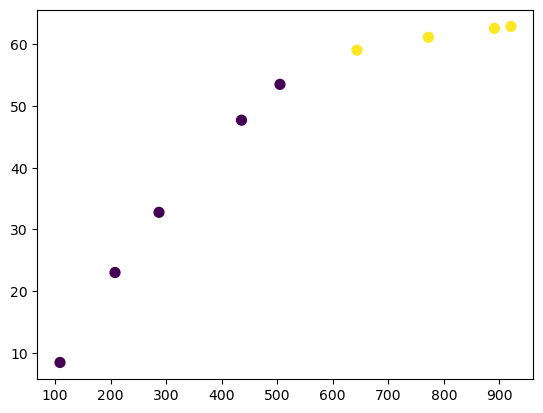

In [84]:
curve_id = 79
plt.scatter(Data["ci"][curve_id],Data["aNet"][curve_id],s = 50,c = Data["ID"][curve_id])
plt.show()